# Ring resonator — an FDTDMEX walkthrough

An end-to-end tour of FDTDMEX on a real photonic device: a **silicon ring resonator** side-coupled to a
bus waveguide. We

1. **author** the layout in **gdstk** (GDS) and convert it to fdtdx geometry,
2. **see** the setup — 2D panels and an interactive **3D** view,
3. **compute & inject** the bus waveguide mode,
4. **expand** the through-port field onto waveguide modes (TE₀, TE₁, TM₀) — the PIC transmission analysis,
5. read it as **S-parameters**,
6. **verify** against an analytical ring model (slab dispersion, resonance, FSR), and
7. hand the simulation off through the portable **HDF5 contract** (`pack` → `run_simulation_from_hdf5` → `sim_postproc`).

> **Resolution note.** This notebook runs on a deliberately **coarse 90 nm grid** so every cell finishes in
> seconds. Numbers (n_eff, transmission, resonance positions) are therefore *illustrative*, not converged —
> a production run would use ≤25 nm. The workflow and APIs are exactly what you'd use at full resolution.

> **Backend note.** On Apple Silicon, supported forward runs auto-route to the **Metal** engine. Mode
> sources/detectors run on the JAX engine for now, so steps 4–6 use JAX; the HDF5 hand-off in step 7 uses
> the Metal forward path.

In [1]:
# --- 1. Imports + materials -------------------------------------------------------------------
import os
import tempfile

import jax.numpy as jnp
import numpy as np

import fdtdx
from fdtdx.objects.static_material.polygon import extruded_polygon_from_gds_path
from fdtdx.utils.plot_setup_3d import plot_setup_3d
from fdtdx.utils.sparams import PortSpec, setup_sparams_simulation

# Render matplotlib figures inline (no-op when this file is run as a plain script).
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # type: ignore[name-defined]
except Exception:
    pass

WAVELENGTH = 1.55e-6
SLAB_T = 0.22e-6  # silicon device-layer thickness
MATERIALS = {"si": fdtdx.Material(permittivity=12.25), "air": fdtdx.Material(permittivity=1.0)}  # n_Si≈3.5

# Ring + bus geometry (micrometres, GDS units).
R, WG, GAP = 1.2, 0.40, 0.10  # ring centerline radius, waveguide width, coupling gap (µm)
# Bus→ring center spacing so there is a real `GAP` between the bus edge and the ring's outer edge:
#   bus half-width (WG/2) + GAP + ring outer radius (R + WG/2)  =  WG + GAP + R.
CY = WG + GAP + R

## 2. Author the layout in gdstk (GDS)
The ring is drawn as a silicon annulus = outer disk (layer 1) with an inner air disk (layer 2) carving
the hole, plus a straight bus waveguide. We render the GDS polygons directly.

wrote /var/folders/zc/ktlm4x1x5574jjwd4trtp3780000gn/T/ring_resonator.gds — 3 polygons


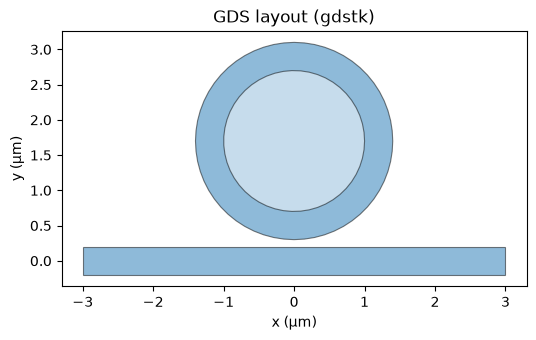

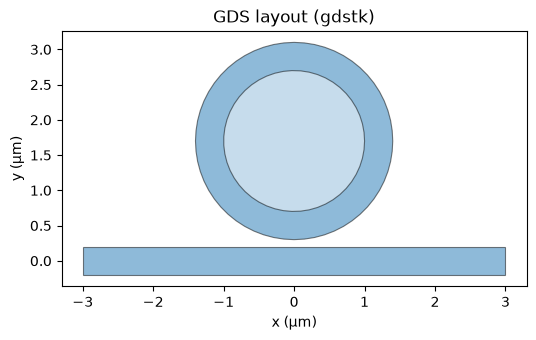

In [2]:
import gdstk

lib = gdstk.Library(unit=1e-6, precision=1e-9)
cell = lib.new_cell("RING")
bus_poly = gdstk.rectangle((-3.0, -WG / 2), (3.0, WG / 2), layer=1)
outer_poly = gdstk.ellipse((0, CY), R + WG / 2, layer=1, tolerance=2e-3)
inner_poly = gdstk.ellipse((0, CY), R - WG / 2, layer=2, tolerance=2e-3)
cell.add(bus_poly, outer_poly, inner_poly)
GDS_PATH = os.path.join(tempfile.gettempdir(), "ring_resonator.gds")
lib.write_gds(GDS_PATH)
print(f"wrote {GDS_PATH} — {len(cell.polygons)} polygons")

# Quick matplotlib render of the GDS layout.
import matplotlib.pyplot as plt

fig_gds, ax = plt.subplots(figsize=(6, 4))
for poly in cell.polygons:
    pts = poly.points
    ax.fill(*pts.T, alpha=0.5, color="tab:blue" if poly.layer == 1 else "white",
            edgecolor="k", lw=0.8)
ax.set_aspect("equal"); ax.set_title("GDS layout (gdstk)"); ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
fig_gds

## 3. Convert GDS → fdtdx geometry (extruded polygons)

In [3]:
def load_ring_polygons():
    """Fresh ExtrudedPolygons (Si bus, Si outer disk, air inner disk), extruded to the slab thickness."""
    def load(layer, idx, mat):
        p = extruded_polygon_from_gds_path(
            GDS_PATH, "RING", layer=layer, polygon_index=idx, axis=2, material_name=mat, materials=MATERIALS
        )
        # GDS gives the transverse footprint; set the out-of-plane (z) thickness to the slab.
        object.__setattr__(p, "partial_real_shape", (p.partial_real_shape[0], p.partial_real_shape[1], SLAB_T))
        return p

    return load(1, 0, "si"), load(1, 1, "si"), load(2, 0, "air")  # bus, outer, inner


bus_p, outer_p, inner_p = load_ring_polygons()
print("bus footprint (µm):", tuple(round(v * 1e6, 2) for v in bus_p.partial_real_shape))
print("ring outer disk (µm):", tuple(round(v * 1e6, 2) for v in outer_p.partial_real_shape))

# Domain (core region, metres) sized to fit the bus + ring + margins.
RES = 90e-9
LX, LZ = 6.4e-6, 0.66e-6
LY = (CY + R + WG + 0.9) * 1e-6  # tall enough to clear the ring's far edge with margin
YBUS = 0.5e-6  # bus y-center inside the core
# (ExtrudedPolygon, core-center-offset). Outer Si disk first, then the air disk carves the hole.
ring_polys = [
    (outer_p, (LX / 2, YBUS + CY * 1e-6, LZ / 2)),
    (inner_p, (LX / 2, YBUS + CY * 1e-6, LZ / 2)),
    (bus_p, (LX / 2, YBUS, LZ / 2)),
]

bus footprint (µm): (6.0, 0.4, 0.22)
ring outer disk (µm): (2.8, 2.8, 0.22)


## 4. Assemble the mode-expansion scene (mode source in, mode monitor out)
`setup_sparams_simulation` builds the background + PML, places the polygons, and adds a `ModePlaneSource`
at the input port and a `ModeOverlapDetector` at the through port.

In [4]:
port_in = [PortSpec(center=(0.8e-6, YBUS, LZ / 2), axis=0, direction="+", width=1.2e-6, height=0.5e-6, name="in")]
port_out = [
    PortSpec(center=(LX - 0.8e-6, YBUS, LZ / 2), axis=0, direction="+", width=1.2e-6, height=0.5e-6, name="through")
]
objects, arrays, config = setup_sparams_simulation(
    polygons=ring_polys, input_ports=port_in, output_ports=port_out,
    wavelength=WAVELENGTH, resolution=RES, max_time=300e-15, domain_size=(LX, LY, LZ), pml_layers=6,
)
print("grid:", tuple(int(x) for x in arrays.inv_permittivities.shape[1:]), "| steps:", config.time_steps_total)

grid: (83, 59, 19) | steps: 1748


## 5. SEE the setup — 2D panels + interactive 3D (the pop-up)

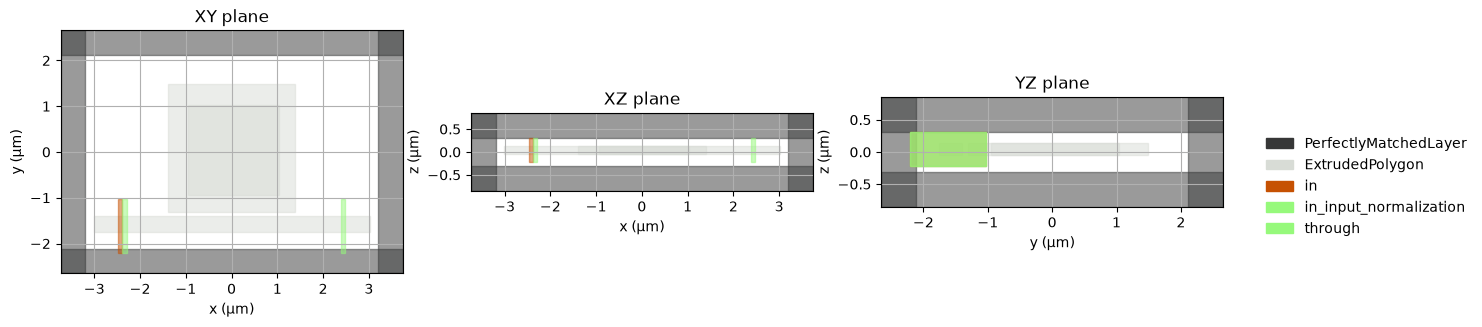

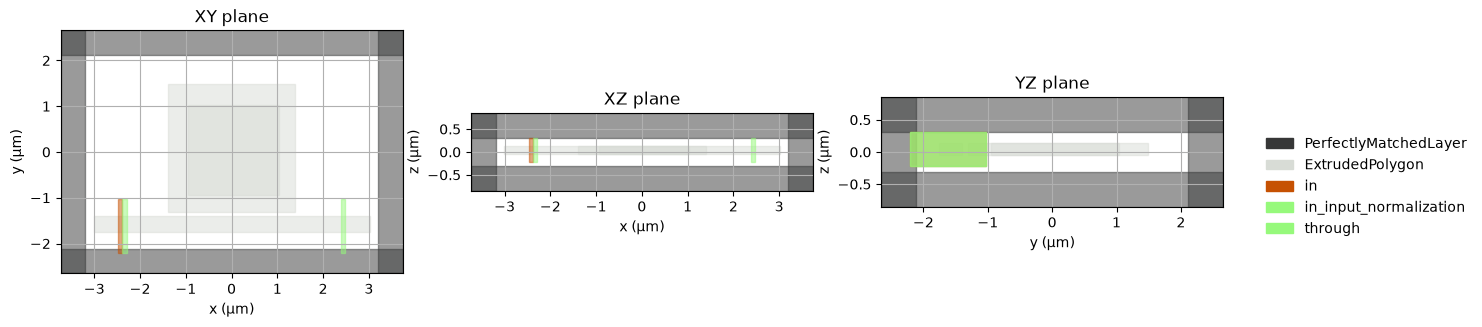

In [5]:
fig_setup = fdtdx.plot_setup(config=config, objects=objects)
fig_setup  # XY / XZ / YZ panels, inline

In [6]:
# Interactive plotly 3D view — drag to rotate. (Needs the `viz` extra: uv sync --extra viz.)
fig3d = plot_setup_3d(config, objects, material_arrays=arrays, show_material=True)
fig3d  # renders inline; in a browser it's fully draggable
# For a web/AG-UI front end, ship it as JSON:  payload = to_plotly_json(fig3d)

## 6. The injected mode — compute + plot the bus-waveguide cross-section

bus fundamental TE n_eff = 2.1912


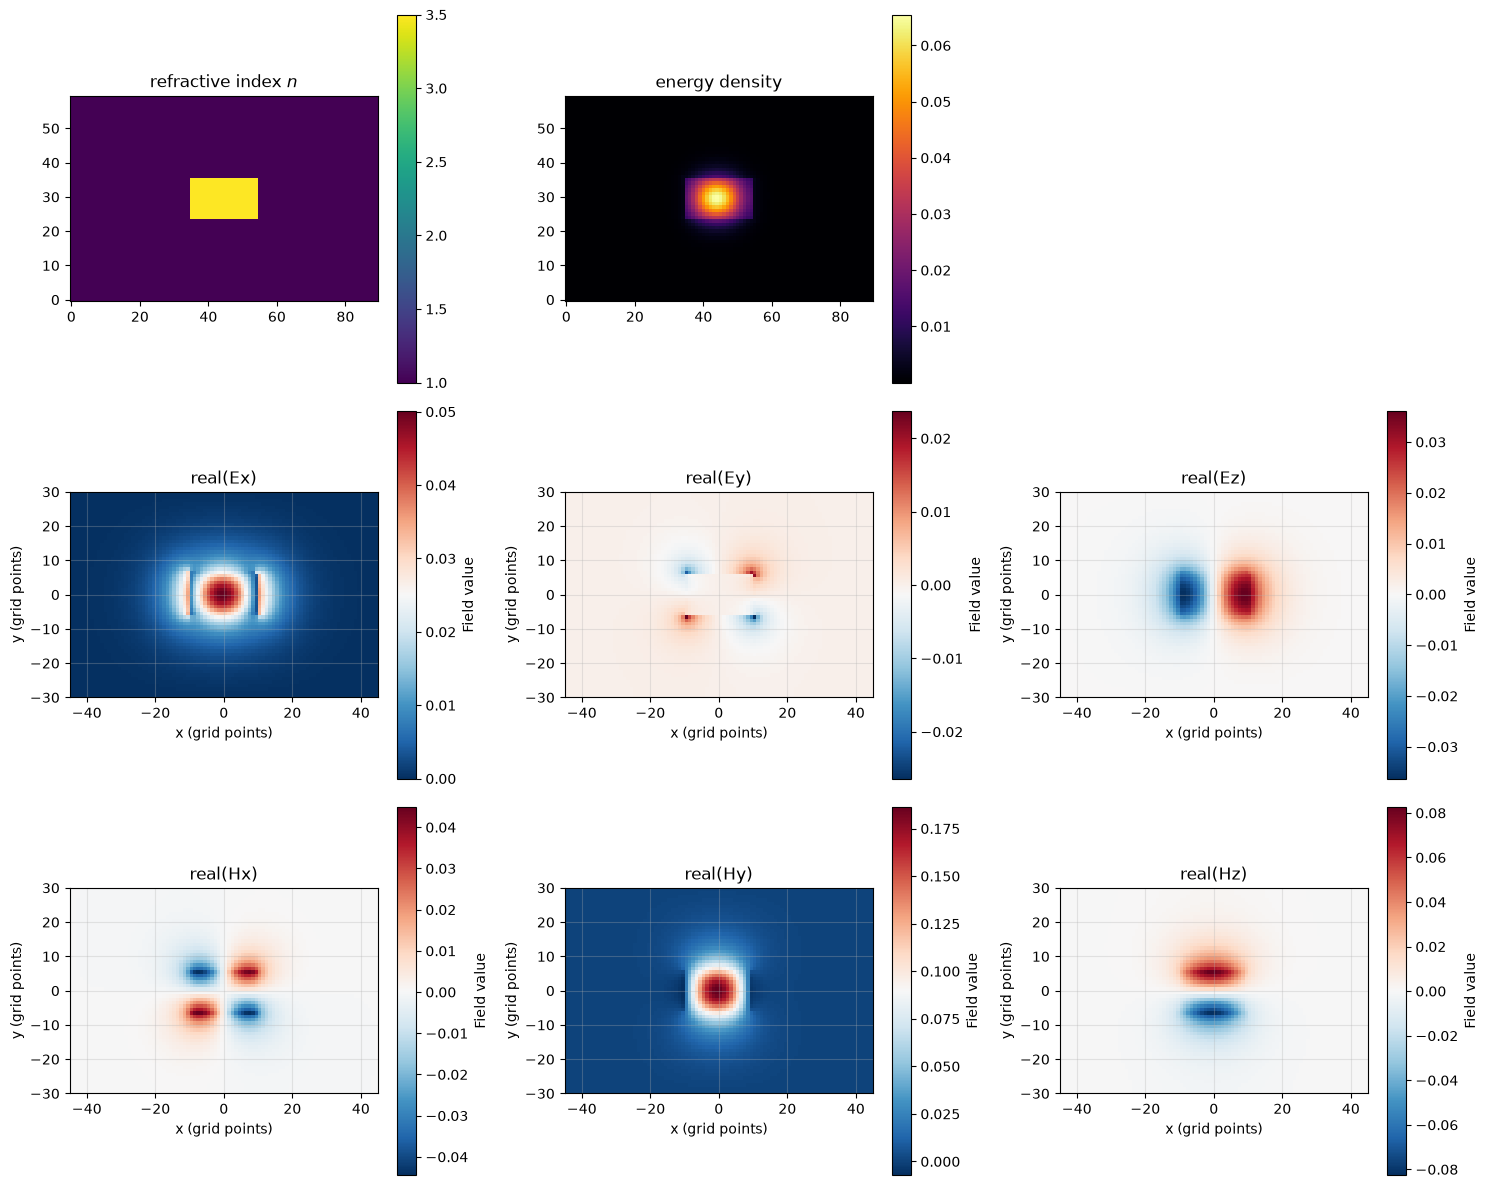

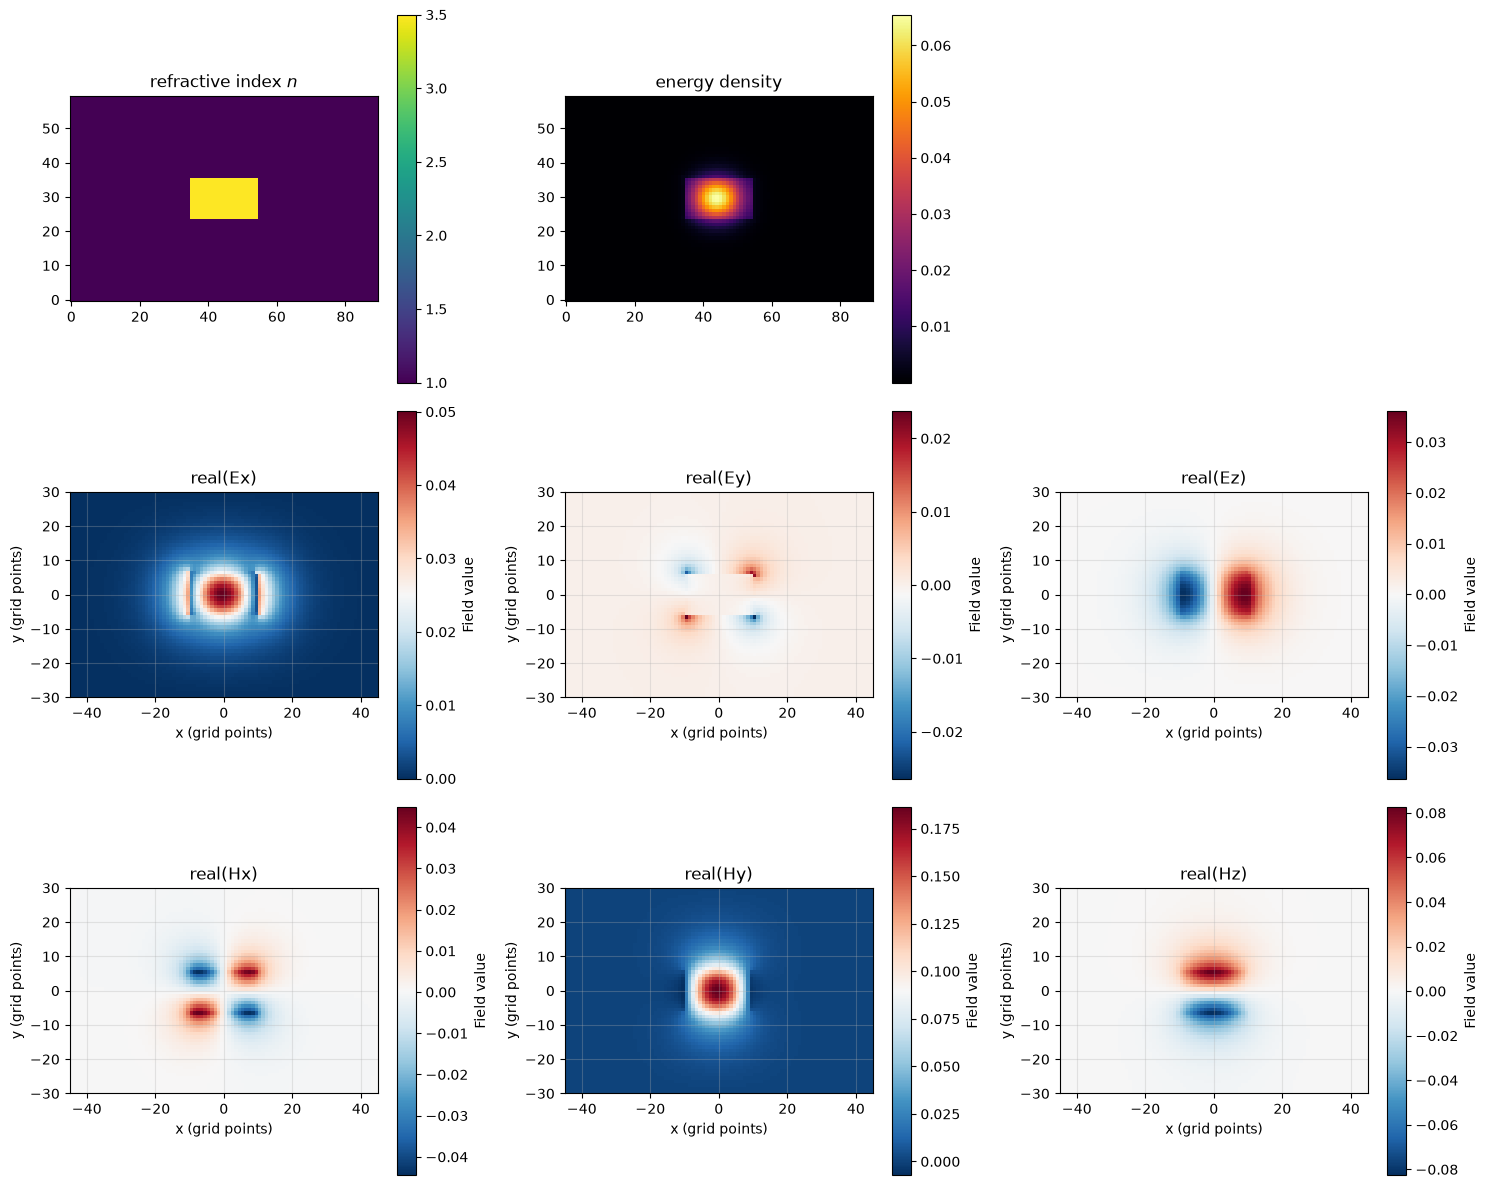

In [7]:
# Build the bus cross-section permittivity (Si core in air) and solve its fundamental TE mode.
res_m = 20e-9
nx, ny = 90, 60
xs = (np.arange(nx) - nx / 2 + 0.5) * res_m
ys = (np.arange(ny) - ny / 2 + 0.5) * res_m
X, Y = np.meshgrid(xs, ys, indexing="ij")
eps_cs = np.where((np.abs(X) <= WG / 2 * 1e-6) & (np.abs(Y) <= SLAB_T / 2), 3.5**2, 1.0**2)
inv_eps_cs = jnp.asarray((1.0 / eps_cs)[None, :, :, None])  # (1, Nx, Ny, 1), z-propagating

E_m, H_m, n_eff = fdtdx.compute_mode(
    frequency=fdtdx.constants.c / WAVELENGTH, inv_permittivities=inv_eps_cs,
    inv_permeabilities=1.0, resolution=res_m, filter_pol="te",
)
print(f"bus fundamental TE n_eff = {complex(n_eff).real:.4f}")
fig_mode = fdtdx.plot_mode(E_m, H_m, inv_permittivity=inv_eps_cs)
fig_mode  # six components + energy + index cross-section

## 7. Modal transmission — decompose the through-port field onto waveguide modes
The PIC quantity of interest: of the light reaching the through port, **how much couples into each
guided mode** (TE₀, TE₁, TM₀, …)? We run the simulation once (input mode source on), then project the
recorded through-port field onto each mode via the overlap integral
`Tₘ = |∫ (Eₘ x H* + E* x Hₘ)·da / α_in|²`. `compute_mode_expansion` solves the reference modes on the
fly — or loads them from a **cache file** (validated against the monitor's cross-section) so repeat
analyses skip the mode solve.

> **Backend note:** this run prints *"MLX backend declined, falling back to JAX"* — expected. Mode
> sources/detectors + custom stopping conditions aren't MLX-eligible yet. The MLX/Metal forward path
> is exercised in section 8.

2026-09-04 18:51:35.527 | WARNING  | fdtdx.backend.dispatch:select_backend:154 - MLX backend declined, falling back to JAX: custom stopping_condition not supported by the MLX backend yet


2026-09-04 18:51:37.763 | INFO     | fdtdx.utils.mode_expansion:compute_mode_expansion:270 - mode expansion: cached 3 mode(s) → ring_through_modes.npz


  mode    n_eff    T (|α/α_in|²)  power share
   TE0    1.724           0.7502        0.952
   TE1    1.000           0.0349        0.044
   TM0    1.093           0.0026        0.003
     Σ                    0.7878        1.000

(modes solved this call: 3)


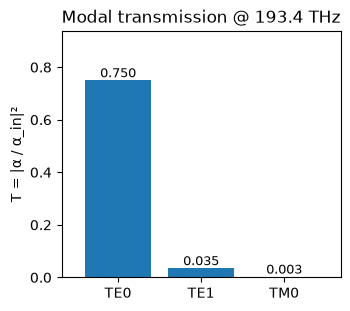

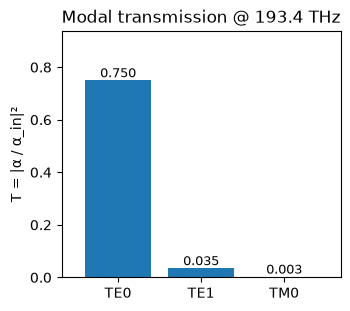

In [8]:
from fdtdx.fdtd.stop_conditions import EnergyThresholdCondition
from fdtdx.utils.sparams import determine_input_norm_detector_name

# Apply (computes each detector's reference mode) + run to steady state.
arrays, objects, _ = fdtdx.apply_params(arrays, objects, {})
_, sim_res = fdtdx.run_fdtd(
    arrays=arrays, objects=objects, config=config, show_progress=False,
    stopping_condition=EnergyThresholdCondition(min_steps=round(config.time_steps_total / 5)),
)
states = sim_res.detector_states

# Incident-mode amplitude at the source (normalizes the transmission).
in_name = determine_input_norm_detector_name("in", objects)
alpha_in = complex(objects[in_name].compute_overlap(states[in_name])[0])

# Decompose the through-port field onto the first two TE modes and the fundamental TM mode.
modes = [("te", 0), ("te", 1), ("tm", 0)]
mode_cache = os.path.join(tempfile.gettempdir(), "ring_through_modes.npz")
if os.path.exists(mode_cache):
    os.remove(mode_cache)
decomp = fdtdx.compute_mode_expansion(
    objects["through"], states["through"], arrays, config, modes, input_overlap=alpha_in, cache_path=mode_cache
)
print(decomp.table())
print(f"\n(modes solved this call: {decomp.n_computed})")
fig_modes = decomp.plot()  # bar chart: transmission per mode
fig_modes

### 7a. The mode cache — solve once, reuse
A second decomposition of the same monitor loads the reference modes from the cache instead of
re-solving. The cache is keyed by the cross-section (grid shape, resolution, frequency, ε hash), so a
*different* monitor would fail the check and recompute — never silently reusing the wrong modes.

In [9]:
decomp2 = fdtdx.compute_mode_expansion(
    objects["through"], states["through"], arrays, config, modes, input_overlap=alpha_in, cache_path=mode_cache
)
print(f"2nd call → modes from cache: {decomp2.n_cached}, recomputed: {decomp2.n_computed}")
print("small JSON result an agent/front-end reads:", decomp2.as_dict())

2026-09-04 18:51:37.819 | INFO     | fdtdx.utils.mode_expansion:compute_mode_expansion:228 - mode expansion: reusing 3 cached mode(s) from ring_through_modes.npz


2nd call → modes from cache: 3, recomputed: 0
small JSON result an agent/front-end reads: {'frequency': 193414489032258.06, 'total_transmission': 0.7878009685879815, 'modes': [{'mode': 'TE0', 'n_eff': [1.724125862121582, 4.9338253044354304e-17], 'transmission': 0.7502262968448906, 'power_fraction': 0.9523043595510703, 's_param': [0.7220403886769164, 0.47841819986720613]}, {'mode': 'TE1', 'n_eff': [1.0, 6.117506864364522e-17], 'transmission': 0.03494484057619854, 'power_fraction': 0.04435744809863851, 's_param': [0.1609592352628953, 0.09506295366641235]}, {'mode': 'TM0', 'n_eff': [1.0932683944702148, 1.7498603517909355e-16], 'transmission': 0.0026298311668924348, 'power_fraction': 0.003338192350291247, 's_param': [-0.049285192506597596, -0.014170425769187433]}]}


### 7b. S-parameters *are* mode-expansion coefficients
In a PIC the scattering matrix is assembled directly from the mode expansion: each S-parameter is the
**complex modal amplitude at a port, normalized to the incident amplitude**. MEEP states it plainly —
its `get_eigenmode_coefficients` returns `alpha[band, freq, 0|1]` (forward | backward coefficients), and
*"the mode coefficient … divided by [the incident] is, by definition, the reflection coefficient"*. So
`|S|² = ` the transmission we just computed and `arg(S)` is the phase. A full S-matrix is just these
coefficients collected over **(port, mode)** pairs. (Reflection `S11` needs a backward-direction monitor
at the input; at finite resolution subtract a reference run to cleanly separate forward/backward, as MEEP
notes.)

In [10]:
# The decomposition already carries the complex S-parameter per mode (magnitude + phase).
for ch in decomp.channels:
    print(f"S(through·{ch.label} ← in·TE0) = {abs(ch.s_param):.3f} ∠ {np.degrees(ch.phase):+.0f}°   (|S|²={ch.transmission:.3f})")

# Assemble them into a mode-resolved S-matrix object (one input mode, the through-port modes):
smat = fdtdx.SMatrixResult.from_sparams(
    {(f"through·{ch.label}", "in·TE0"): np.array([ch.s_param]) for ch in decomp.channels},
    frequencies=[decomp.frequency],
)
print("\nS-matrix entries (mode-resolved):", {f"{o}←{i}": round(abs(v[0]), 3) for (o, i), v in smat.data.items()})

S(through·TE0 ← in·TE0) = 0.866 ∠ +34°   (|S|²=0.750)
S(through·TE1 ← in·TE0) = 0.187 ∠ +31°   (|S|²=0.035)
S(through·TM0 ← in·TE0) = 0.051 ∠ -164°   (|S|²=0.003)

S-matrix entries (mode-resolved): {'through·TE0←in·TE0': np.float64(0.866), 'through·TE1←in·TE0': np.float64(0.187), 'through·TM0←in·TE0': np.float64(0.051)}


## 8. Analytical ring resonator model — a solid verification
A ring resonator's behavior is set by two physics pieces we can predict analytically and check against the
solver:
1. **Resonance + free spectral range (FSR)** from the round-trip phase: resonances occur when
   `n_eff·L = m·λ` (L = 2πR), spaced by `FSR = λ²/(n_g·L)` with the **group index** `n_g`.
2. **Coupling** set by the gap via the evanescent field — a coupled-mode / perturbation estimate
   `κ ∝ exp(-gap/L_decay)`.

First, the **anchor**: verify the mode solver (which the whole mode expansion rests on) against the
**exact** symmetric-slab dispersion relation `κ·tan(κw/2) = γ`.

In [11]:
from fdtdx.core.physics.mode_backend.operator import build_derivative_matrices
from fdtdx.core.physics.mode_backend.solve import solve_modes_diagonal


def analytic_slab_te0(n_core, n_clad, width, k0):
    """Fundamental even-TE n_eff of a symmetric slab (largest root of κ·tan(κw/2)=γ)."""
    def disp(ne):
        return k0 * np.sqrt(n_core**2 - ne**2) * np.tan(k0 * np.sqrt(n_core**2 - ne**2) * width / 2) - k0 * np.sqrt(
            ne**2 - n_clad**2
        )
    ns = np.linspace(n_clad + 1e-6, n_core - 1e-6, 400000)
    v = disp(ns)
    return max(0.5 * (ns[i] + ns[i + 1]) for i in range(len(ns) - 1) if v[i] * v[i + 1] < 0 and abs(v[i]) < 1e6)

n_core, n_clad, w_slab = 3.0, 1.0, 0.30e-6
k0 = 2 * np.pi / WAVELENGTH
r = 5e-9
Nx = 200
edges = (np.arange(Nx + 1) - Nx / 2) * r
xc = 0.5 * (edges[:-1] + edges[1:])
eps_slab = np.where(np.abs(xc) <= w_slab / 2, n_core**2, n_clad**2)
der = build_derivative_matrices(edges, np.array([0.0, r]), (False, False))
ones = np.ones(Nx)
_, _, neff_num, _ = solve_modes_diagonal(eps_slab, eps_slab, eps_slab, ones, ones, ones, der, k0, 6, n_core, "+")
n_solver = float(np.real(np.asarray(neff_num).ravel()[0]))
n_exact = analytic_slab_te0(n_core, n_clad, w_slab, k0)
print(f"slab n_eff:  solver = {n_solver:.4f}   analytic = {n_exact:.4f}   relative error = {abs(n_solver - n_exact) / n_exact:.1e}")

slab n_eff:  solver = 2.5391   analytic = 2.5398   relative error = 2.4e-04


### 8a. Ring resonance, FSR and finesse from the bus mode
Solve the bus mode at three nearby wavelengths to get `n_eff` and `n_g = n_eff − λ·dn_eff/dλ`, then apply
the analytical ring formulas.

In [12]:
def bus_neff(wl, res):
    nx, ny = round(2.0e-6 / res), round(1.2e-6 / res)
    X, Y = np.meshgrid((np.arange(nx) - nx / 2 + 0.5) * res, (np.arange(ny) - ny / 2 + 0.5) * res, indexing="ij")
    eps = np.where((np.abs(X) <= WG / 2 * 1e-6) & (np.abs(Y) <= SLAB_T / 2), 3.5**2, 1.0**2)
    _, _, ne = fdtdx.compute_mode(
        frequency=fdtdx.constants.c / wl, inv_permittivities=np.asarray((1.0 / eps)[None, :, :, None]),
        inv_permeabilities=1.0, resolution=res, filter_pol="te",
    )
    return float(np.real(ne))

L_ring = 2 * np.pi * (R * 1e-6)  # circumference (m)
dl = 10e-9
n_eff = bus_neff(WAVELENGTH, RES)
n_g = n_eff - WAVELENGTH * (bus_neff(WAVELENGTH + dl, RES) - bus_neff(WAVELENGTH - dl, RES)) / (2 * dl)
FSR = WAVELENGTH**2 / (n_g * L_ring)
m0 = round(n_eff * L_ring / WAVELENGTH)  # resonance order nearest 1.55 µm
resonances = [n_eff * L_ring / m for m in (m0 + 1, m0, m0 - 1)]
print(f"n_eff = {n_eff:.3f},  n_g = {n_g:.3f},  L = 2πR = {L_ring * 1e6:.2f} µm")
print(f"FSR = λ²/(n_g·L) = {FSR * 1e9:.1f} nm")
print(f"resonance order m₀ = {m0};  nearby resonances (nm): {[round(x * 1e9, 1) for x in resonances]}")

# Gap → coupling (coupled-mode / perturbation estimate): the cladding evanescent decay length sets κ.
gamma = 2 * np.pi / WAVELENGTH * np.sqrt(max(n_eff**2 - 1.0, 1e-6))
L_decay = 1 / gamma
print(f"\ncladding decay length 1/γ = {L_decay * 1e9:.0f} nm  ⇒  κ ∝ exp(−gap/L_decay);"
      f"  at gap={GAP * 1e3:.0f} nm → {np.exp(-GAP * 1e-6 * gamma):.2f}")

# Finesse / Q for an example self-coupling t (lossless ring, a=1):
for t in (0.97, 0.90):
    finesse = np.pi * np.sqrt(t) / (1 - t)
    Q = WAVELENGTH / (FSR / finesse)
    print(f"  t={t}: κ²={1 - t**2:.3f}  finesse={finesse:.1f}  FWHM={FSR / finesse * 1e9:.2f} nm  Q≈{Q:.0f}")

n_eff = 2.252,  n_g = 5.025,  L = 2πR = 7.54 µm
FSR = λ²/(n_g·L) = 63.4 nm
resonance order m₀ = 11;  nearby resonances (nm): [1415.2, 1543.9, 1698.3]

cladding decay length 1/γ = 122 nm  ⇒  κ ∝ exp(−gap/L_decay);  at gap=100 nm → 0.44
  t=0.97: κ²=0.059  finesse=103.1  FWHM=0.61 nm  Q≈2521
  t=0.9: κ²=0.190  finesse=29.8  FWHM=2.13 nm  Q≈729


### 8b. Analytical all-pass transmission + an FDTD FSR check
The textbook all-pass through-port transmission is
`T(λ) = (a² − 2at·cosφ + t²)/(1 − 2at·cosφ + a²t²)`, `φ = 2π·n_eff·L/λ`. We overlay a short FDTD
wavelength sweep of the through-port **mode-expansion** transmission. The demo grid is coarse, so the
absolute dip depths are noisy and shifted, but the **resonance spacing matches the analytical FSR** — the
geometry-set quantity that survives coarse resolution.

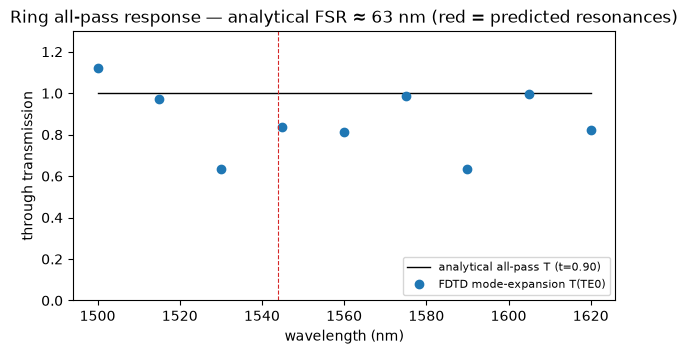

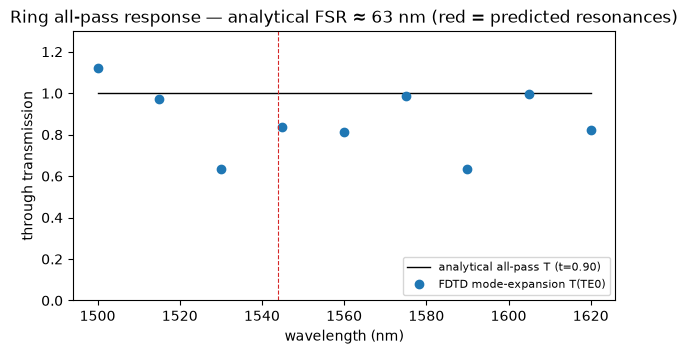

In [13]:
def allpass_T(wl, t=0.90, a=1.0):
    phi = 2 * np.pi * n_eff * L_ring / wl
    return (a**2 - 2 * a * t * np.cos(phi) + t**2) / (1 - 2 * a * t * np.cos(phi) + (a * t) ** 2)

sweep_wl = np.linspace(1.50e-6, 1.62e-6, 9)
sweep_T = []
for wl in sweep_wl:
    b, ot, it = load_ring_polygons()  # fresh polygons per run
    sweep_polys = [(ot, (LX / 2, YBUS + CY * 1e-6, LZ / 2)), (it, (LX / 2, YBUS + CY * 1e-6, LZ / 2)),
                   (b, (LX / 2, YBUS, LZ / 2))]
    o, a, c = setup_sparams_simulation(
        polygons=sweep_polys,
        input_ports=[PortSpec(center=(0.8e-6, YBUS, LZ / 2), axis=0, direction="+", width=1.2e-6, height=0.5e-6, name="in")],
        output_ports=[PortSpec(center=(LX - 0.8e-6, YBUS, LZ / 2), axis=0, direction="+", width=1.2e-6, height=0.5e-6, name="thru")],
        wavelength=wl, resolution=RES, max_time=500e-15, domain_size=(LX, LY, LZ), pml_layers=6,
    )
    a, o, _ = fdtdx.apply_params(a, o, {})
    _, sr = fdtdx.run_fdtd(arrays=a, objects=o, config=c, show_progress=False,
                           stopping_condition=EnergyThresholdCondition(min_steps=round(c.time_steps_total / 3)))
    s = sr.detector_states
    inn = determine_input_norm_detector_name("in", o)
    ain = complex(o[inn].compute_overlap(s[inn])[0])
    sweep_T.append(fdtdx.compute_mode_expansion(o["thru"], s["thru"], a, c, [("te", 0)], input_overlap=ain).channels[0].transmission)
sweep_T = np.array(sweep_T)

fine = np.linspace(1.50e-6, 1.62e-6, 600)
fig_ring, axr = plt.subplots(figsize=(7, 3.5))
axr.plot(fine * 1e9, [allpass_T(w) for w in fine], "k-", lw=1, label="analytical all-pass T (t=0.90)")
axr.plot(sweep_wl * 1e9, sweep_T, "o", color="tab:blue", label="FDTD mode-expansion T(TE0)")
for rwl in [r for r in resonances if 1.50e-6 <= r <= 1.62e-6]:
    axr.axvline(rwl * 1e9, color="tab:red", ls="--", lw=0.8)
axr.set_xlabel("wavelength (nm)"); axr.set_ylabel("through transmission"); axr.set_ylim(0, 1.3)
axr.set_title(f"Ring all-pass response — analytical FSR ≈ {FSR * 1e9:.0f} nm (red = predicted resonances)")
axr.legend(loc="lower right", fontsize=8)
fig_ring

## 9. Portable hand-off — `Scene` → HDF5 → results → small reductions
The contract between the front end and any compute node (local, remote, or an LLM-driven agent): a
self-contained config HDF5 carries the **resolved** arrays, and only the small JSON config and the
reduced `sim_postproc` outputs ever need to leave the machine.

This forward path runs on the **Metal** engine, so we illuminate the same ring with a
`GaussianPlaneSource` + `EnergyDetector` and build it with the `Scene` facade.

In [14]:
from fdtdx.objects.boundaries.initialization import BoundaryConfig, boundary_objects_from_config


def build_ring_scene():
    """Background + PML + ring polygons + a Gaussian plane source into the bus + an energy detector."""
    pml = 6
    total = (LX + 2 * pml * RES, LY + 2 * pml * RES, LZ + 2 * pml * RES)
    volume = fdtdx.SimulationVolume(partial_real_shape=total, material=MATERIALS["air"], name="Background")
    constraints, object_list = [], [volume]

    bcfg = BoundaryConfig.from_uniform_bound(thickness=pml, boundary_type="pml")
    bdict, bcons = boundary_objects_from_config(bcfg, volume)
    object_list += list(bdict.values()); constraints += bcons

    def center_at(obj, off):
        return obj.place_relative_to(
            volume, axes=(0, 1, 2), own_positions=(0, 0, 0), other_positions=(-1, -1, -1),
            margins=(off[0] + pml * RES, off[1] + pml * RES, off[2] + pml * RES),
        )

    b, o, i = load_ring_polygons()
    for poly, off in [(o, (LX / 2, YBUS + CY * 1e-6, LZ / 2)), (i, (LX / 2, YBUS + CY * 1e-6, LZ / 2)),
                      (b, (LX / 2, YBUS, LZ / 2))]:
        object_list.append(poly); constraints.append(center_at(poly, off))

    source = fdtdx.GaussianPlaneSource(
        partial_grid_shape=(1, None, None), partial_real_shape=(None, 1.2e-6, 0.5e-6),
        fixed_E_polarization_vector=(0, 0, 1), wave_character=fdtdx.WaveCharacter(wavelength=WAVELENGTH),
        radius=0.5e-6, std=1 / 3, direction="+",
    )
    constraints.append(center_at(source, (0.8e-6, YBUS, LZ / 2)))
    object_list.append(source)

    detector = fdtdx.EnergyDetector(name="energy")
    constraints += detector.same_position_and_size(volume)
    object_list.append(detector)
    return fdtdx.Scene(config=fdtdx.SimulationConfig(time=120e-15, grid=fdtdx.UniformGrid(spacing=RES))).add(
        *object_list
    ).constrain(constraints)


sim = build_ring_scene()
sim  # _repr_html_ summary (object / source / detector counts, time steps)

objects,12
sources,1 ['Object_99']
detectors,1 ['energy']
constraints,12
time,1.200e-13 s (699 steps)
placed,False
ran,False


### 9a. Pack to a portable bundle in a project folder (`pack`)

In [15]:
import json
import time

from fdtdmex.io import SceneModel, pack, run_simulation_from_hdf5, sim_postproc, sim_run

project = tempfile.mkdtemp(prefix="ring_project_")
bundle = pack(sim, project)  # content-addressed HDF5 + lightweight config JSON sidecar
print("packed bundle:", os.path.basename(bundle.hdf5_path), "| config hash:", bundle.config_hash)

import h5py

with h5py.File(bundle.hdf5_path, "r") as f:
    print("config.hdf5 groups:", list(f.keys()))
    print("  steps:", int(f.attrs["num_steps"]), "| detectors:", int(f.attrs["n_detectors"]))
    print("  payload arrays:", len(f["payload"]["arrays"].keys()), "datasets (resolved ε/µ/σ + source/detector plans)")

2026-09-04 18:52:08.547 | INFO     | fdtdmex.io.pack:pack:258 - pack: wrote bundle → /var/folders/zc/ktlm4x1x5574jjwd4trtp3780000gn/T/ring_project_rtl4zow5/7459f6f4d5f62654.hdf5 (hash=7459f6f4d5f62654, 699 steps, 1 detectors)


packed bundle: 7459f6f4d5f62654.hdf5 | config hash: 7459f6f4d5f62654
config.hdf5 groups: ['config', 'grid', 'meta', 'payload']
  steps: 699 | detectors: 1
  payload arrays: 30 datasets (resolved ε/µ/σ + source/detector plans)


### 9b. Launch it non-blocking (`run_simulation_from_hdf5`) — the agent-facing flow

In [16]:
# The launcher stages a job folder under `jobs/`, copies the bundle in, and detaches the solver —
# returning immediately while `status.json` advances queued→running→completed. Here we use the
# GPU-free `mock` backend (what the agentic workspace develops against) and poll to completion.
jobs = os.path.join(project, "jobs")
job = run_simulation_from_hdf5(bundle, jobs, backend="mock", name="ring-cold")
print("launched (non-blocking):", job.run_id, "→", os.path.relpath(job.job_dir, project))

for _ in range(600):                      # up to 60 s: the child is a fresh interpreter, not instant
    status = json.loads(job.status_path.read_text())
    if status["status"] in ("completed", "failed"):
        break
    time.sleep(0.1)
print("final status:", status["status"], "| results:", os.path.exists(job.results_path))
print("mock postproc:", sim_postproc(job.results_path)["backend"])

2026-09-04 18:52:08.576 | INFO     | fdtdmex.io.launch:run_simulation_from_hdf5:210 - run_simulation_from_hdf5: launched run '75b5aac76eb0-ae9f0e71' (backend=mock, pid=41310) → /var/folders/zc/ktlm4x1x5574jjwd4trtp3780000gn/T/ring_project_rtl4zow5/jobs/75b5aac76eb0-ae9f0e71


launched (non-blocking): 75b5aac76eb0-ae9f0e71 → jobs/75b5aac76eb0-ae9f0e71


final status: completed | results: True
mock postproc: mock


### 9b′. Bit-identity oracle (`sim_run`, the low-level primitive)

In [17]:
# `sim_run` is the bare engine executor — handy for showing the packed run is bit-identical to a
# direct `run_fdtd`. (The agent doesn't call this; `run_simulation_from_hdf5` does, in its child.)
res_h5 = os.path.join(tempfile.gettempdir(), "ring_results.hdf5")
sim_run(bundle, res_h5, backend="mlx")  # runs the Metal engine directly (no JAX in the loop)

# Confirm this scene is MLX-eligible (Gaussian source + energy detector, no custom stopping condition).
from fdtdx.backend.dispatch import select_backend

sim.place()
backend = select_backend(sim.arrays, sim.objects, sim.config, None).value
print("Scene forward backend:", backend, "→ MLX/Metal" if backend == "mlx" else "(JAX)")

# Oracle: the same Scene run in-process (auto-routes to the same MLX backend).
direct = sim.run()
direct_energy = np.asarray(direct.detector_states["energy"]["energy"])
with h5py.File(res_h5, "r") as f:
    packed_energy = np.asarray(f["detector_states"]["energy"]["energy"])
print("max |direct − packed| =", float(np.max(np.abs(direct_energy - packed_energy))), "(0.0 ⇒ bit-identical)")

2026-09-04 18:53:00.323 | INFO     | fdtdmex.io.run:sim_run:97 - sim_run: wrote results HDF5 → /var/folders/zc/ktlm4x1x5574jjwd4trtp3780000gn/T/ring_results.hdf5 (backend=mlx, 699 steps)


Scene forward backend: mlx → MLX/Metal


max |direct − packed| = 0.0 (0.0 ⇒ bit-identical)


### 9c. Small reductions (`sim_postproc`) + the editable JSON config (`SceneModel`)

In [18]:
reduced = sim_postproc(res_h5)
print("postproc backend:", reduced["backend"], "| detectors:", list(reduced["detectors"]))
print("energy summary:", reduced["detectors"]["energy"]["energy"])

# The pydantic SceneModel is the small, editable JSON config a reactive window (pydantic-ai / AG-UI /
# FastAPI) mutates. It carries each object as its fdtdx export tree (incl. polygon vertices) and
# round-trips as JSON.
model = sim.to_model()
model_json = model.model_dump_json()
print(f"\nSceneModel JSON: {len(model_json)} bytes, {model.n_objects} objects")
print("object summary (what the UI lists):", [f"{o.type}" for o in model.objects])

# JSON round-trip (what the reactive window saves + reloads):
model_again = SceneModel.model_validate_json(model_json)
print("JSON round-trip OK:", model_again.describe()["n_objects"] == model.n_objects)
# Lowering the JSON back to live objects (`.to_json_setup() -> place_objects`) reconstructs the
# standard primitives losslessly (see tests/validation/test_io_roundtrip.py); GDS-derived
# ExtrudedPolygons carry derived geometry and are a known reconstruction follow-up.

postproc backend: mlx | detectors: ['energy']
energy summary: {'shape': [699, 83, 59, 19], 'dtype': 'float32', 'max_abs': 0.07360077649354935, 'mean_abs': 4.903176522930153e-05, 'sum': 3188.881591796875}

SceneModel JSON: 30924 bytes, 12 objects
object summary (what the UI lists): ['SimulationVolume', 'PerfectlyMatchedLayer', 'PerfectlyMatchedLayer', 'PerfectlyMatchedLayer', 'PerfectlyMatchedLayer', 'PerfectlyMatchedLayer', 'PerfectlyMatchedLayer', 'ExtrudedPolygon', 'ExtrudedPolygon', 'ExtrudedPolygon', 'GaussianPlaneSource', 'EnergyDetector']
JSON round-trip OK: True


## Recap
- **gdstk** authored the ring → **`ExtrudedPolygon`** fdtdx geometry.
- **`plot_setup`** + **`plot_setup_3d`** (interactive plotly) showed the setup; `to_plotly_json` makes it web-ready.
- **`compute_mode`** + **`plot_mode`** gave the injected bus mode; **`compute_mode_expansion`** projected the
  through-port field onto TE₀/TE₁/TM₀ (with a validated mode cache) — the PIC modal-transmission result.
- **`Scene`** + **`pack`/`run_simulation_from_hdf5`/`sim_postproc`** + the **mock** backend + **`SceneModel`** are
  the agentic hand-off — non-blocking detached launch, bit-identical to a direct run, GPU-free where needed,
  and JSON-round-tripping for a reactive UI.